<img src = "https://drive.google.com/uc?export=view&id=1Md0grlXXV4fB0bkYuMWzBiS64RvjaFGX" alt = "Encabezado MLDS" width = "100%">  </img>

# **Entendimiento del Negocio y Carga de Datos**
---

## **0. Integrantes del equipo de trabajo**
---

Por favor incluya los nombres completos y número de identificación de los integrantes del equipo de trabajo:

1. Ivonne Alexandra Guevara Prieto - CC 1032376081

## **1. Marco de Proyecto**
---

### **1.1. Trasfondo del Negocio**
---

- ¿Quién es el cliente o los beneficiarios del proyecto? ¿En qué dominio se encuentran (marketing, medicina, entre otros)?
- ¿Qué problemas del negocio o del dominio estamos tratando de solucionar?

**RESPUESTA**

---

### Beneficiarios del proyecto

Este proyecto se ubica en el dominio de la **seguridad financiera y documental**. Los principales beneficiarios son:

* **Sector financiero:** Entidades bancarias y aseguradoras que procesan diariamente miles de documentos firmados (cheques, contratos, pólizas).
* **Sector legal y judicial:** Notarías y registros públicos, tribunales y juzgados, despachos de abogados que requieren verificar la autenticidad de firmas en documentos legales.
* **Sector gubernamental:** Registradurías y cancillerías que gestionan documentos oficiales con alto valor legal.

### Problemas del dominio que se buscan resolver

La falsificación de firmas es una de las fuentes de fraude más comunes en operaciones financieras y legales. En 2023, las pérdidas relacionadas con este tipo de fraude rondaron los US\$26 mil millones $^{[1]}$. El incremento de falsificación de firmas digitales se estima en un 244% para 2025, convirtiéndolo en la fuente primaria de fraude de identidad $^{[2]}$. En el sector bancario, se estima que el 94% de las entidades han sido afectadas por robo de identidad, con un costo cercano a US\$0.5 millones por incidente. En Australia, las pérdidas por este tipo de fraude en 2025 alcanzaron los AUD\$335 millones, siendo la falsificación de firmas el método más frecuente $^{[1]}$. Este aumento ha sido potenciado por la popularización de la IA. Se ha encontrado, además, que el 75.6% de los reportes médicos falsificados para hacer reclamaciones fraudulentas a aseguradoras usaron falsificación de firmas $^{[3]}$.

Los problemas centrales que este proyecto busca resolver son:

* **Fraude documental** — La falsificación de firmas genera pérdidas millonarias anuales en los sectores financiero y legal.
* **Limitaciones del proceso manual de detección** — La verificación humana es lenta, costosa, subjetiva y propensa a errores, especialmente bajo volúmenes altos de documentos.
* **Escalabilidad** — Las instituciones procesan miles de documentos diariamente, lo que hace inviable una revisión pericial humana en tiempo real.
* **Trazabilidad y auditoría** — Se necesita un sistema que no solo detecte adulteraciones, sino que también genere registros verificables de cada decisión tomada.
* **Reducción de falsos positivos/negativos** — Un sistema automatizado bien entrenado puede equilibrar mejor la sensibilidad y especificidad que un revisor humano bajo presión.

---

**Referencias:**

[1] Nasdaq Verafin. (2024). *Global Financial Crime Report*. https://verafin.com/nasdaq-verafin-global-financial-crime-report/

[2] PactVera. (2025). *2026 E-Signature Fraud Statistics*. https://www.pactvera.com/2026-e-signature-fraud-statistics/

[3] Elsayed AS, Mwaheb MA, Elsary AY, El Rashed K, Saleh AR. Awareness and perception of physicians about forgery and counterfeiting in the medical field in Egypt. *Sci Rep.* 2025 Apr 19;15(1):13549. doi: 10.1038/s41598-025-93729-4.

### **1.2. Alcance**
---

- ¿Qué  solución basada en _Deep Learning_ queremos implementar?
- ¿Qué  se hará?
- Cuáles son los límites y fronteras del proyecto de análisis de datos? ¿Qué aspectos específicos del negocio se incluirán y cuáles se excluyen en el alcance del proyecto?
- ¿De qué forma el cliente o beneficiario utilizará el producto del proyecto?

**RESPUESTA**

---

### Solución propuesta

Se implementará un sistema de **verificación automática de firmas** basado en redes neuronales profundas. El núcleo del sistema es una **Red Siamesa (Siamese Network)** con una arquitectura CNN como red base. Este tipo de red está diseñado para comparar pares de imágenes y medir su similitud, lo que lo hace ideal para detectar falsificaciones con pocos ejemplos de entrenamiento por clase.

**Tipo de problema ML:** Clasificación binaria de pares de firmas → 1: genuino / 0: adulterado.

**Arquitectura propuesta:**
* **Red base CNN:** Extrae características visuales (trazos, presión, inclinación) de cada imagen de firma.
* **Redes Siamesas:** Dos redes neuronales "ramificadas" con pesos compartidos procesan simultáneamente la firma de referencia y la firma sospechosa.
* **Distancia L1:** Mide la diferencia entre los vectores de características de ambas ramas para producir un score de similitud.
* **Transfer Learning (comparación):** Se usará un modelo preentrenado (EfficientNet) como línea base de comparación para evaluar el desempeño relativo de la red Siamesa.

### ¿Qué se hará?

1. Recopilación y carga del dataset de firmas (CEDAR: 1372 imágenes de firmas genuinas y falsificadas).
2. Análisis exploratorio y preprocesamiento de imágenes (normalización, redimensionamiento a 105×105 px).
3. Construcción de pares de imágenes etiquetados para entrenamiento de la Red Siamesa.
4. Implementación, entrenamiento y validación del modelo con TensorFlow/Keras.
5. Evaluación con métricas: accuracy, precision, recall, F1-score y AUC-ROC.
6. Interpretación de resultados en el contexto del negocio.

### Límites y fronteras del proyecto

**Incluido en el alcance:**
* Verificación de firmas manuscritas análogas digitalizadas.
* Detección de falsificaciones hábiles (*skilled forgery*) y aleatorias (*random forgery*).
* Generación de un score de confianza por cada par verificado.
* Comparación de la Red Siamesa contra Transfer Learning como línea base.

**Excluido del alcance:**
* Verificación de firmas digitales o electrónicas certificadas.
* Reconocimiento de escritura manuscrita general (OCR).
* Verificación de sellos, timbres o rúbricas institucionales.
* Soporte para grafologías no latinas (árabe, mandarín, etc.).
* Toma autónoma de decisiones legales — el sistema es de **apoyo**, no reemplaza al perito.

### Uso del producto por parte del cliente

Los clientes y usuarios podrán utilizar el sistema para comparar una firma sospechosa contra una firma de referencia almacenada. El modelo devolverá un **score de confianza** y los reportes de trazabilidad generados podrán usarse como insumo de apoyo en procesos de investigación o litigios. El sistema clasifica cada verificación en tres niveles de acción:

| Score | Resultado | Acción recomendada |
|---|---|---|
| > 0.90 | Genuina | Aprobación automática |
| 0.60 – 0.89 | Incierto | Revisión humana complementaria |
| < 0.60 | Adulterada | Rechazo y alerta de fraude |

Los entregables finales consistirán en: (1) Reporte mediante notebooks documentados con el análisis completo, (2) el modelo entrenado con recomendaciones al implementar y (3) un video de presentación del proyecto.

### **1.3. Plan**
---

A continuación se presenta el plan de trabajo del proyectoby mapeado a los entregables del proyecto.


**RESPUESTA**

----

### -  Plan de trabajo

| Fase | Actividad | Entregable |
|---|---|---|
| **1. Entendimiento del negocio** | Definición del problema, objetivo, alcance y plan | Marco de proyecto completo |
| **2. Entendimiento de los datos** | Carga del dataset CEDAR, verificación de integridad  | Dataset cargado y verificado |
| **3. Preparación de los datos** | EDA, análisis descriptivo, visualizaciones, preprocesamiento | Datos limpios y pares de entrenamiento |
| **4. Modelado** | Diseño de la Red Siamesa, implementación, partición, data augmentation  | Arquitectura implementada |
| **5. Evaluación** | Entrenamiento, selección de hiperparámetros, métricas, interpretación  | Modelo evaluado + video |

**Criterios de éxito del proyecto:**
* AUC-ROC ≥ 0.95 sobre el conjunto de prueba.
* Equal Error Rate (EER) ≤ 5%.
* Tiempo de inferencia por par de firmas < 2 segundos.


#### - Exclusiones

    Este proyecto no incluye:
        - Verificación de firmas digitales o electrónicas certificadas
        - Reconocimiento de escritura manuscrita general (OCR)
        - Verificación de sellos, timbres o rúbricas institucionales
        - Soporte para documentos en idiomas con alfabetos no latinos
        - Implementación de las soluciones propuestas
        - Modelos de detección automática


#### - Resumen del cronograma

| Tarea | Fecha esperada de finalización | Descripción/Detalles |
| ----------- | -------------------- |----------- |
|Entendimiento del negocio y carga de datos |	27/03/2026	|Definición de los objetivos del negocio y del proyecto. Planeación. Carga y obtención de datos.  transformación de los datos y partición del conjunto de datos.|
|Entendimiento y preparación de los datos|	09/04/2026|	Procesamiento y análisis preliminar de los datos mediante un EDA. Visualización de los datos.Preprocesamiento.|
|Diseño e implementación	|16/04/2026|Diseño y selección del modelo de Deep Learning.  Implementación del modelo.|
|Entrenamiento y validación	|23/04/2026	|Entrenamiento del modelo. Diseño de experimentación, construcción y entrenamiento de modelos, y definición de los criterios o métricas de evaluación.|
|Entrega de reporte final	|27/04/2026	|Evaluación del modelo con métricas de desempeño. Interpretación de los resultados. Finalización y entrega del reporte final.|



### **1.4. Objetivo del Proyecto en Términos de ML**
---

**RESPUESTA**

---

El objetivo central del proyecto en términos de *machine learning* es entrenar una **Red Siamesa con arquitectura CNN base** que, dado un par de imágenes de firmas $(A, B)$, produzca un score de similitud $s \in [0, 1]$ tal que:

$$s = \sigma(W \cdot |f(A) - f(B)|)$$

donde $f(\cdot)$ es la función de embedding aprendida por la CNN y $\sigma$ es la función sigmoide. El modelo deberá:

* **Clasificar correctamente** el par como genuino ($s > 0.5$) o adulterado ($s \leq 0.5$).
* **Minimizar** la función de pérdida *binary cross-entropy* durante el entrenamiento.
* **Maximizar** el AUC-ROC sobre el conjunto de prueba como métrica principal de desempeño.

| Parámetro | Valor |
|---|---|
| Tipo de problema | Clasificación binaria (por pares) |
| Arquitectura | Siamese Network + CNN base |
| Función de pérdida | Binary Cross-Entropy |
| Métrica principal | AUC-ROC |
| Métrica secundaria | Accuracy, F1-score, EER |
| Objetivo AUC-ROC | ≥ 0.95 |

## **2. Datos**
---

En esta sección debe adjuntar una descripción de los datos y agregar el código que permite su tratamiento.

### **2.1. Origen**
---

- ¿De dónde vienen los datos? ¿Cuál es la fuente principal de los datos?
- ¿Existen consideraciones especiales al extraer datos de esta fuente?
- ¿Se usa alguna herramienta o proceso para la descarga de la información?
- ¿Qué tipo de datos estamos manejando?

**RESPUESTA**

----

**Conjunto de datos:** ICDAR 2011 Signature Verification$^{[4]}$

La colección contiene muestras de firmas tanto en formato físico como digital. El conjunto de datos físico incluye imágenes PNG escaneadas a 400 ppp en color RGB. El conjunto de datos digital incluye archivos ASCII con el formato X, Y, Z (por línea). Total de firmas en línea: 449; total de firmas fuera de línea: 362. Se utilizó papel preimpreso con 12 casillas numeradas (59 mm de ancho y 23 mm de alto). Este papel se colocó debajo del papel en blanco. Se añadieron cuatro hojas en blanco adicionales debajo de las dos primeras para asegurar una superficie de escritura suave.

Frecuencia de muestreo de 200 Hz, resolución de 2000 líneas/cm, precisión de 0,25 mm.
Dispositivo de captura: Tableta gráfica USB WACOM Intuos3 A3 Wide.
Software de recopilación: MovAlyzer.

* Las firmas genuinas se nombran según la siguiente convención (la misma para todos los conjuntos de datos): NN _III.*, donde NN es un índice de la firma y III es la ID del escritor de referencia, es decir, es la NN-ésima firma auténtica aportada por el escritor III.

* Las firmas simuladas (falsificaciones) se nombran según las siguientes convenciones: NN _FFFFIII.*, donde NN es un índice, FFFF es la ID del falsificador e III es la ID del escritor de referencia, es decir, es el NNº intento de simulación del falsificador FFFF para simular la firma del escritor III.

Data format: png.


----
[4] Marcus Liwicki, Michael Blumenstein, Elisa van den Heuvel, Charles EH Berger, Reinoud D. Stoel, Bryan Found, Xiaohong Chen, Muhammad Imran Malik. "SigComp11: Competición de verificación de firmas para falsificaciones expertas en línea y fuera de línea", Actas de la 11.ª Conferencia Internacional sobre Análisis y Reconocimiento de Documentos, 2011.

### **2.2. Carga o Adquisición de Datos**
---

Agregue el código necesario en _Python_ para obtener o cargar los datos.

In [2]:
#Manejo de archivos
import os
import pandas as pd

#Manejo de textos
import re

#Manejo de imagenes
import numpy as np
import matplotlib.pyplot as plt

import keras

print(f'Keras: {keras.__version__}')

Keras: 3.13.2


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robinreni/signature-verification-dataset")

print("Path to dataset files:", path)


100%|██████████| 601M/601M [00:07<00:00, 86.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robinreni/signature-verification-dataset/versions/2


In [4]:
#folders
path_train = os.path.join(path, "sign_data/train")
path_test = os.path.join(path, "sign_data/test")
path_sign_data = os.path.join(path, "sign_data/sign_data")

#csv
train_csv = pd.read_csv(os.path.join(path, "sign_data/train_data.csv"))
test_csv = pd.read_csv(os.path.join(path, "sign_data/test_data.csv"))

In [9]:
train_csv.head()

,068/09_068.png,068_forg/03_0113068.PNG,label,image_real_paths,image_forged_paths
0,068/09_068.png,068_forg/01_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
1,068/09_068.png,068_forg/02_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
2,068/09_068.png,068_forg/01_0113068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
3,068/09_068.png,068_forg/04_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
4,068/09_068.png,068_forg/04_0113068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...


In [10]:
test_csv.head()

,068/09_068.png,068_forg/03_0113068.PNG,label,image_real_paths,image_forged_paths
0,068/09_068.png,068_forg/01_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
1,068/09_068.png,068_forg/02_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
2,068/09_068.png,068_forg/01_0113068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
3,068/09_068.png,068_forg/04_0124068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...
4,068/09_068.png,068_forg/04_0113068.PNG,1,/root/.cache/kagglehub/datasets/robinreni/sign...,/root/.cache/kagglehub/datasets/robinreni/sign...


In [5]:
import pandas as pd
import os

# Train data
train_csv.rename(columns={"1":"label"}, inplace=True)
train_csv["image_real_paths"] = train_csv["068/09_068.png"].apply(lambda x: os.path.join(path_train, x))
train_csv["image_forged_paths"] = train_csv["068_forg/03_0113068.PNG"].apply(lambda x: os.path.join(path_train, x))

# Test data
test_csv.rename(columns={"1":"label"}, inplace=True)
test_csv["image_real_paths"] = test_csv["068/09_068.png"].apply(lambda x: os.path.join(path_test, x))
test_csv["image_forged_paths"] = test_csv["068_forg/03_0113068.PNG"].apply(lambda x: os.path.join(path_test, x))

In [ ]:
train_csv.head()

,068/09_068.png,068_forg/03_0113068.PNG,label,image_real_paths,image_forged_paths
0,068/09_068.png,068_forg/01_0124068.PNG,1,/kaggle/input/signature-verification-dataset/s...,/kaggle/input/signature-verification-dataset/s...
1,068/09_068.png,068_forg/02_0124068.PNG,1,/kaggle/input/signature-verification-dataset/s...,/kaggle/input/signature-verification-dataset/s...
2,068/09_068.png,068_forg/01_0113068.PNG,1,/kaggle/input/signature-verification-dataset/s...,/kaggle/input/signature-verification-dataset/s...
3,068/09_068.png,068_forg/04_0124068.PNG,1,/kaggle/input/signature-verification-dataset/s...,/kaggle/input/signature-verification-dataset/s...
4,068/09_068.png,068_forg/04_0113068.PNG,1,/kaggle/input/signature-verification-dataset/s...,/kaggle/input/signature-verification-dataset/s...


In [ ]:
test_csv.head()

,068/09_068.png,068_forg/03_0113068.PNG,1
0,068/09_068.png,068_forg/01_0124068.PNG,1
1,068/09_068.png,068_forg/02_0124068.PNG,1
2,068/09_068.png,068_forg/01_0113068.PNG,1
3,068/09_068.png,068_forg/04_0124068.PNG,1
4,068/09_068.png,068_forg/04_0113068.PNG,1


In [6]:
from matplotlib import image
# Loading the image
from PIL import Image
image1_path = train_csv["image_real_paths"][0]
image2_path = train_csv["image_forged_paths"][0]
img0 = Image.open(image1_path)
img1 = Image.open(image2_path)
img0 = img0.convert("L")
img1 = img1.convert("L")

In [7]:
real_images = []
for image_path in train_csv["image_real_paths"]:
    img = Image.open(image_path)
    img = img.convert("L")  # Convert to grayscale
    real_images.append(img)

print(f"Loaded {len(real_images)} real images.")
# You can inspect the first image in the list, for example:
# real_images[0]

Loaded 23205 real images.


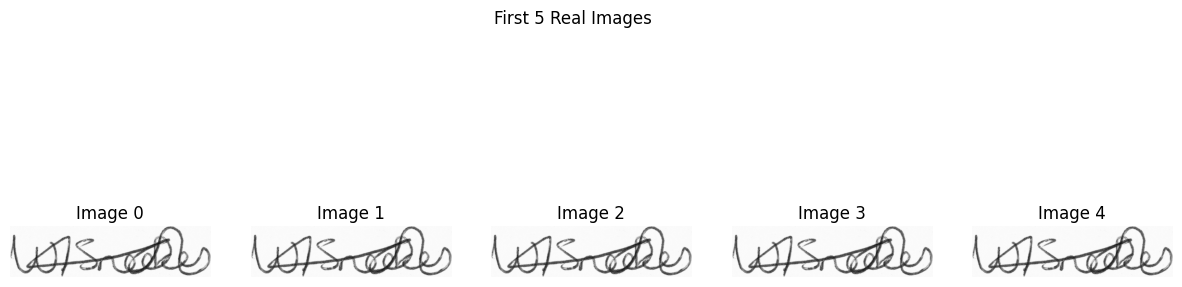

In [8]:
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(real_images[i], cmap='gray')
    plt.title(f'Image {i}')
    plt.axis('off')
plt.suptitle('First 5 Real Images')
plt.show()

## **Créditos**

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*